## Build a model from Python

In this example a simple **SFINCS** compound flood model will be made, using the underlying Python functions of **HydroMT-SFINCS** to build a model.

The model is situated in **Northern Italy**, where a small selection of topography and bathymetry data has already been made available for you to try the examples.

In [1]:
import os
from datetime import datetime

from hydromt_sfincs import SfincsModel, DATADIR
from hydromt._utils import log

# Initialize logging, the lower the log level number, the more verbose (more info) the output
# NOTSET=0-9, DEBUG=10, INFO=20, WARNING=30, ERROR=40, CRITICAL=50

log.initialize_logging()
log.set_log_level(log_level=20)

This example shows how to build a SFINCS model containing elevation data and spatially varying roughness (together processed into subgrid tables), and add simple water level boundary conditions.

In case you want to adjust this example to build a SFINCS model anywhere else in the world, you will have to add your own datasets to HydroMT's data catalog. For more info on that, check-out:

- [Prepare data catalog](https://deltares.github.io/hydromt/stable/guides/advanced_user/data_prepare_cat.html)

- [Example: Prepare data catalog](https://deltares.github.io/hydromt/stable/_examples/prep_data_catalog.html)

**Steps followed in this notebook to build your SFINCS model:**
<ol> 
<li> Open SfincsModel class, set data library and output folder </li>
<li> Specify characteristics of the wanted grid </li>
<li> Load in wanted elevation datasets </li>
<li> Make mask of active and inactive cells </li>
<li> Update mask with water level and outflow boundary cells</li>
<li> Add spatially varying roughness data</li>
<li> Make subgrid derived tables</li>
<li> Add water level time-series as forcing</li>
<li> Inspect the model and boundary conditions</li>
<li> Write simple model to disk</li>
</ol> 

Let's get started!

### 1. Initialize SfincsModel class, set data library and output folder:

Before we can use all the tools provided by HydroMT-SFINCS, we have to initialize the SfincsModel instance. This creates a shortcut to all the model components and methods to read, write and create these components. Furthermore, when initializing the model, we can specify which data catalog we use and where the model is/will be stored (the root).

In [2]:
# Initialize SfincsModel Python class with the artifact data catalog which contains publically available data for North Italy
sf = SfincsModel(
    data_libs=["artifact_data"],  # specify which data libraries to use
    root="tmp_sfincs_compound",  # specify the root directory for the model
    mode="w+",  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite
    write_gis=True,  # specify whether to write GIS data
)

2026-03-06 12:12:04,159 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2026-03-06 12:12:04,161 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2026-03-06 12:12:05,611 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-03-06 12:12:05,611 - hydromt.model.model - model - WARNING - No region component found in components.


### 2. Specify characteristics of the wanted grid and generate grid:

The easiest way in HydroMT-SFINCS to generate a grid is by starting from a region and a resolution. This region can be a bounding box, or a shapefile/geojson that for example describes a watershed or administrative boundary. 

For more info about how to define a grid, [click here](https://sfincs.readthedocs.io/en/latest/input.html#grid-characteristics). 

In [3]:
sf.grid.create_from_region(
    region={"geom": "data/region.geojson"},  # specify the region geometry
    res=50,  # specify the resolution
    rotated=True,  # specify whether the grid is rotated
    crs="utm",  # specify the coordinate reference system, when "utm", the UTM zone is automatically detected
)

2026-03-06 12:12:25,818 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading region.geojson GeoDataFrame data from c:\Data\TUD\MSc_CE\Courses\2nd_year\7.CIE5060_Thesis\Codes\MSc_thesis_hydromt_sfincs\examples\data\region.geojson
2026-03-06 12:12:25,908 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 9 attributes in model config.


The grid that we just created is described in the SFINCS configuration with x0, y0, dx, dy, mmax, nmax, rotation and epsg. In case you would have known these parameters before, you can also create a grid using `SfincsModel.grid.create()`.

In [4]:
# the input file is automatically updated. See:
sf.config.data.model_dump()

{'mmax': 251,
 'nmax': 108,
 'dx': 50.0,
 'dy': 50.0,
 'x0': 318650.0,
 'y0': 5040000.0,
 'rotation': 27.0,
 'tref': datetime.datetime(2026, 3, 6, 0, 0),
 'tstart': datetime.datetime(2026, 3, 6, 0, 0),
 'tstop': datetime.datetime(2026, 3, 7, 0, 0),
 'tspinup': None,
 't0out': None,
 't1out': None,
 'dtmapout': 3600.0,
 'dtmaxout': 86400.0,
 'dtrstout': None,
 'trstout': None,
 'dthisout': 600.0,
 'dtwave': None,
 'dtwnd': None,
 'alpha': 0.5,
 'theta': 1.0,
 'hmin_cfl': None,
 'manning': None,
 'manning_land': 0.04,
 'manning_sea': 0.02,
 'rgh_lev_land': 0.0,
 'zsini': 0.0,
 'qinf': 0.0,
 'dtmax': None,
 'huthresh': 0.01,
 'rhoa': None,
 'rhow': None,
 'inputformat': 'bin',
 'outputformat': 'net',
 'outputtype_map': None,
 'outputtype_his': None,
 'nc_deflate_level': None,
 'bndtype': None,
 'advection': 1,
 'nfreqsig': None,
 'freqminig': None,
 'freqmaxig': None,
 'latitude': 0.0,
 'pavbnd': None,
 'gapres': None,
 'baro': 1,
 'utmzone': None,
 'epsg': 32633,
 'advlim': None,
 'slope

HydroMT-SFINCS has so very usefull tools to plot your model and all of its components. The main functionality to plot the model can be found in `SfincsModel.plot_basemap()` where you can specify which background map (`bmap`) to use, and which layers to plot. Throughout this notebook, we will explore the different options of this method.

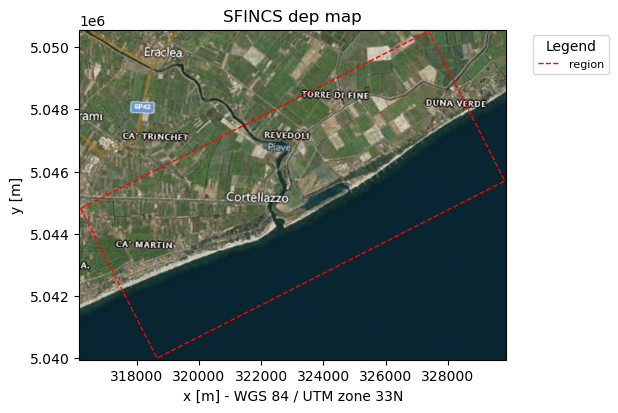

In [5]:
# show the model grid outline
_ = sf.plot_basemap(plot_region=True, bmap="sat", zoomlevel=12)

### 3. Add elevation to the model

Probably the most important datasets to create a proper SFINCS model are the digital elevation models (DEMs). However, often there are different datasets for describing the elevation on land, topography, and below water, bathymetry. HydroMT-SFINCS provides functionality to merge these different datasets onto the model grid.

2026-03-06 13:52:04,203 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\matti\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2026-03-06 13:52:04,366 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\matti\.hydromt\artifact_data\latest\gebco.tif


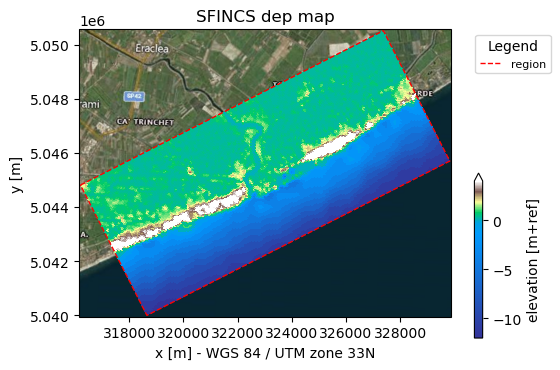

In [6]:
# In this example we want to combine 2 elevation datasets, merit_hydro as elevation and gebco as bathymetry, in that order.
# NOTE: from the 1st dataset (merit_hydro) only elevation above ("zmin":0.001) meters is used;
# the 2nd elevation dataset (gebco) is used where the 1st dataset returned nodata values
elevation_list = [{"elevation": "merit_hydro", "zmin": 0.001}, {"elevation": "gebco"}]

# Add depth information to modelgrid based on these chosen datasets
sf.elevation.create(elevation_list=elevation_list, buffer_cells=1)

# Make a plot of the merged topobathy, here colour limits are set between an elevation of -5 to 5 meters
_ = sf.plot_basemap(variable="dep", plot_region=True, bmap="sat", zoomlevel=12)

### 4. Make mask of active and inactive cells:

The next step of building a SFINCS model is to create a mask. First we generate a mask of active (msk=1) and inactive cells (msk=0), determining in which cells of your computational grid water levels will be computed.

For more info about the msk-file, [click here](https://sfincs.readthedocs.io/en/latest/input.html#mask-file). 

2026-03-06 13:53:11,967 - hydromt.hydromt_sfincs.components.grid.mask - mask - INFO - 1 gaps outside valid elevation range < 10.0 km2.
2026-03-06 13:53:11,973 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 2 attributes in model config.


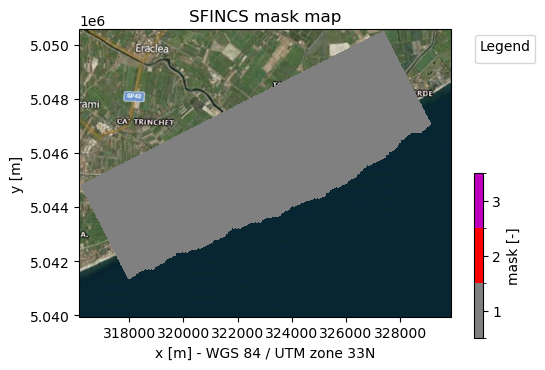

In [7]:
# Defining your active cells can be based on multiple criteria, here we only specify a minimum elevation of -5 meters,
# meaning all cells above -5 are considered to be active. Check-out the method documentation for more options.
sf.mask.create_active(zmin=-5)

# # Make a plot of the mask file
_ = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=True, bmap="sat", zoomlevel=12
)

NOTE:
- The given output of HydroMT says "1 gap outside valid elevation range < 10 km2". 
HydroMT does some smart filtering that if small groups of inactive cells are found, surrounded by active cells, these are still included as active, in this case 1 gap.
You can control the size of these gaps to filter by adding `fill_area = 10` in `SfincsModel.mask.create_active()`.
- A similar argument exists to neglect a group of active cells surrounded by inactive cells: `drop_area`

### 5. Update mask with water level and outflow boundary cells - including use of polygons:

In SFINCS you can specify cells where you want to force offshore water levels (mask=2), or outflow boundaries (mask=3). To determine these cells, there are again multiple criteria to use, such as elevation or user-defined-polygons. Below we present both.

In [8]:
# Here we add water level cells along the coastal boundary, for cells up to an elevation of -5 meters
sf.mask.create_boundary(
    btype="waterlevel",
    zmax=-5,
    reset_bounds=True,
)

2026-03-06 13:57:08,340 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


In [9]:
# Here we add outflow cells, only where clicked in shapefile along part of the lateral boundaries
gdf_include = sf.data_catalog.get_geodataframe(
    "data//compound_example_outflow_boundary_polygon.geojson"
)
sf.mask.create_boundary(
    btype="outflow",
    include_polygon=gdf_include,
    reset_bounds=True,
)

2026-03-06 13:58:31,509 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading compound_example_outflow_boundary_polygon.geojson GeoDataFrame data from c:\Data\TUD\MSc_CE\Courses\2nd_year\7.CIE5060_Thesis\Codes\MSc_thesis_hydromt_sfincs\examples\data\compound_example_outflow_boundary_polygon.geojson
2026-03-06 13:58:31,603 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


<GeoAxes: title={'center': 'SFINCS mask map'}, xlabel='x [m] - WGS 84 / UTM zone 33N', ylabel='y [m]'>

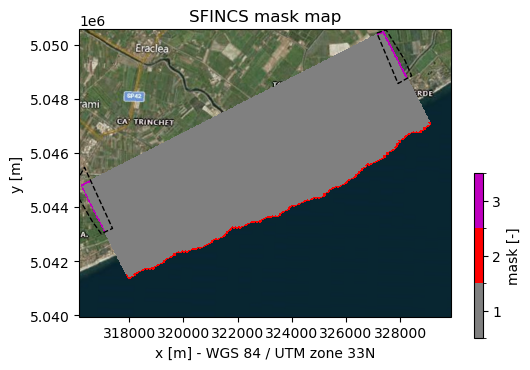

In [10]:
# Make a plot of the mask file
fig, ax = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=False, bmap="sat", zoomlevel=12
)
# plot the shapefile given by the user as dashed line
gdf_include.to_crs(sf.crs).boundary.plot(ax=ax, color="k", lw=1, ls="--")

NOTE:
- As you can see now, also msk=2 values (red line) have been added along the coastal boundary
- As you can see now, also msk=3 values (purple line) have been added along the lateral inland boundaries within the gdf_include shapefile
- `reset_bounds=True` means that you start without initial boundary cells (of the specified type), if `reset_bounds=False` (default) you build on the existing boundary cells (if available)

### 6. Add spatially varying roughness data:

Next to the elevation, the roughness is also an important input dataset for the SFINCS model. Typically, the mannings' n roughness coefficients are derived based on landuse/landcover data and a conversion table.

2026-03-06 14:00:05,079 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading vito_2015 RasterDataset data from C:\Users\matti\.hydromt\artifact_data\latest\vito.tif
2026-03-06 14:00:05,113 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading vito_mapping.csv DataFrame data from c:\Users\matti\miniconda3\envs\hydromt-sfincs-test\Lib\site-packages\hydromt_sfincs\data\lulc\vito_mapping.csv
2026-03-06 14:00:05,131 - hydromt.gis.raster - raster - WARNING - The nodata value None is not in the reclass table.None will be used for the params.
2026-03-06 14:00:05,246 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - INFO - Set other manning options to None in config that are unused in SFINCS in case of specifying manningfile (manning, manning_land, manning_sea, rgh_lev_land).


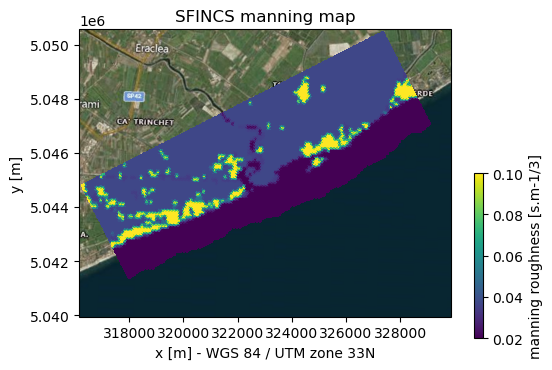

In [11]:
# Some reclass tables are available in the hydromt_sfincs DATADIR
# e.g. vito_mapping.csv for vito_2015 landuse classification
reclass_table = os.path.join(DATADIR, "lulc", "vito_mapping.csv")

# use the river manning raster in combination with vito_2015 land to derive the manning roughness file
roughness_list = [{"lulc": "vito_2015", "reclass_table": reclass_table}]

sf.roughness.create(
    roughness_list=roughness_list,
    manning_land=0.04,
    manning_sea=0.02,
    rgh_lev_land=0,  # the minimum elevation of the land
)
_ = sf.plot_basemap(variable="manning", plot_bounds=False, bmap="sat", zoomlevel=12)

### 7. Make subgrid derived tables:

Subgrid derived tables are used to better capture the elevation and roughness of your domain, to either improve your results, or to allow you to run on a courser grid resolution (means faster simulation). For more info about subgrid tables, [click here](https://sfincs.readthedocs.io/en/latest/developments.html#recent-advancements-in-accuracy-subgrid-mode). 

You as user can specify multiple settings about how the subgrid derived tables should be made.

Every single grid cell of the flux grid of the size inp.dx by inp.dy is defined into subgrid pixels (default nr_subgrid_pixels = 20).
For every subgrid pixel the topobathy data is loaded, ideally this consists of high-resolution DEM datasets that you specify as user.

In this example with dx=dy=50m, having nr_subgrid_pixels = 20 means we are loading data onto a 2.5 m subpixel grid
However, the input data of Gebco and Merit_hydro is way coarser, therefore let's set the ratio to 6 for now.

    
<div style="border-left: 4px solid #4CAF50; padding: 0.5em; background-color: #f0fff0;">
<b>⚠️ Note:</b> The subgrid tables replace the elevation and roughness data that we prepared before!
</div>

For the subgrid tables, we again provide the elevation datasets, and roughness datasets. Additonally, we can provide river datasets that are used to burn in rivers into the elevation and roughness maps. 

In [12]:
# Repeat elevation and roughness sets for clarity
elevation_list = [{"elevation": "merit_hydro", "zmin": 0.001}, {"elevation": "gebco"}]

# Roughness sets
roughness_list = [{"lulc": "vito_2015", "reclass_table": reclass_table}]

sf.subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    nr_subgrid_pixels=6,
    write_dep_tif=True,
    write_man_tif=True,
)

# NOTE: we turned on that the merged topobathy of the different (high-res) datasets is written to a geotiff

2026-03-06 14:10:51,952 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\matti\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2026-03-06 14:10:51,988 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\matti\.hydromt\artifact_data\latest\gebco.tif
2026-03-06 14:10:52,022 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading vito_2015 RasterDataset data from C:\Users\matti\.hydromt\artifact_data\latest\vito.tif
2026-03-06 14:10:52,053 - hydromt.data_catalog.data_catalog - data_catalog - WARNING - overwriting data source 'vito_mapping.csv' with provider user and version _UNSPECIFIED_.
2026-03-06 14:10:52,054 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading vito_mapping.csv DataFrame data from c:\Users\matti\miniconda3\envs\hydromt-sfincs-test\Lib\site-packages\hydromt_sfincs\data\lulc\vito_mapping.csv
202

<div style="border-left: 4px solid #4CAF50; padding: 0.5em; background-color: #f0fff0;">
<b>⚠️ Note:</b> If you have a very large domain with more than a millions cells, and very high-resolution datasets (e.g. 1 m), this step might take minutes to hours!!! 

But good news; when finished succesfully, you can very quickly run very accurate SFINCS simulations! The whole point of the subgrid functionality of SFINCS is that by derived subgrid tables based on high res elevation data, you either have more accurate results or run on a coarser grid resolution (= much faster) or both.
</div>


Now we can see what kind of subgrid-derived variables are created:

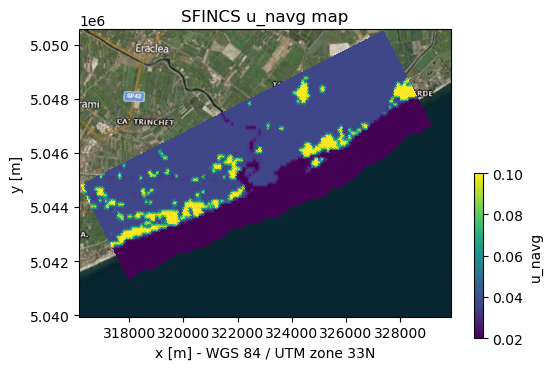

In [ ]:
# uncomment to see the subgrid table variales
# sf.subgrid.data

# we can plot the 2D subgrid variables
_ = sf.plot_basemap(
    variable=sf.subgrid.data["u_navg"], plot_bounds=False, bmap="sat", zoomlevel=12
)

### 8. Add water level time-series as forcing:

There are many ways to add **water level boundary conditions** to the SFINCS model. We introduce one in the example below, check out the [WaterLevel](https://deltares.github.io/hydromt_sfincs/stable/_generated/hydromt_sfincs.components.forcing.SfincsWaterLevel.html) component for more options:

**🌐 Using a geodataset (presented here)**  
- The simplest option.  
- Contains time series of water levels at specific points.  
- Often generated by other models, such as the **GTSM model**.

In [16]:
# Change period of model simulation time, specified in yyyymmdd HHMMSS, to match with the available water level data
sf.config.update(
    {
        "tref": datetime(2010, 2, 5),
        "tstart": datetime(2010, 2, 5),
        "tstop": datetime(2010, 2, 7),
    }
)

# From geodataset
sf.water_level.create(geodataset="gtsmv3_eu_era5")

2026-03-06 14:15:33,967 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 3 attributes in model config.
2026-03-06 14:15:34,031 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gtsmv3_eu_era5 GeoDataset data from C:\Users\matti\.hydromt\artifact_data\latest\gtsmv3_eu_era5.nc


### 9. Inspect the model and boundary conditions

To inspect the added boundary conditions, we can again use the plotting functionality of HydroMT-SFINCS. When the boundary conditions are related to boundary points (water levels and waves), these locations can be visualzied with `SfincsModel.plot_basemap(plot_geoms=True)`. Nonetheless, the actual timeseries of the boundary conditions can be visualized with `SfincsModel.plot_forcing()`.

(<Figure size 600x428.571 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS dep map'}, xlabel='x [m] - WGS 84 / UTM zone 33N', ylabel='y [m]'>)

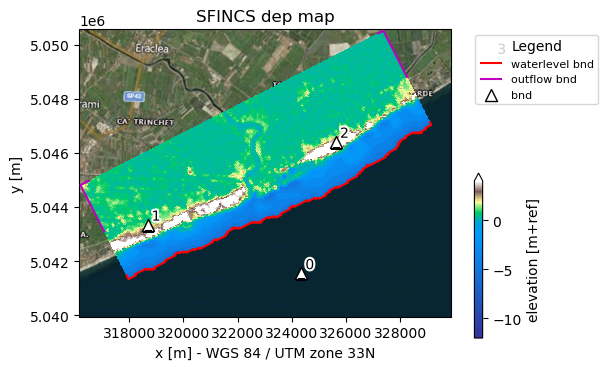

In [17]:
# plot basemap, in this case boundary points should be added (and plotted because of plot_geoms=True)
sf.plot_basemap(
    variable="dep", plot_geoms=True, plot_bounds=True, bmap="sat", zoomlevel=12
)

And the boundary conditions timeseries:

In [ ]:
sf.plot_forcing()

### 10. Write the model input to disk

By now we have made all basic SFINCS spatial layers and added simple water level boundary conditions. We are ready to write the model to disk, and run the model. 

In [18]:
# write all model files to disk
sf.write()

We always recommend to run the SFINCS model with normal conditions first to check model performance (we don't expect flooding under normal conditions). To run this basic model, you could progress to the notebook: 
- [Run the model](4_run_model.ipynb)

If you noticed something strange in your results, or want to increase the complexity of your model (e.g. more realistic boundary conditions), you can update your model. This is demonstrated in the following notebooks:
- [Update Forcing](2_update_forcing.ipynb)
- [Update Geometries](3_update_geometries.ipynb)


<div style="border-left: 4px solid #4CAF50; padding: 0.5em; background-color: #f0fff0;">
<b>⚠️ Note:</b> Building a model is an iterative process. Combining the different notebooks in this tutorial series allows you to build more complex models step-by-step.
</div>